# Langevin Dynamics


In [1]:
import matplotlib.pyplot as plt
import numba
import numpy as np
import scipy.constants

import mvdlib.diffusion
import mvdlib.plots

plt.style.use("mvdlib.style.default")

In [2]:
NSTEPS = 1_000_000
DT = 0.001

MASS = 18.0
DIFF = 0.003
TEMP = 300.0

KT = scipy.constants.gas_constant * TEMP / 1000.0
FRICTION = KT / DIFF
NSAMPLES = 50

FORCE_CONSTANT = 1000.0
POTENTIAL_WIDTH = 1.5

FRICTION_SCALE = 5000.0
FRICTION_WIDTH = 0.04

FIGSIZE = mvdlib.plots.FigSize()

## Free Particle

We start by simulating Langevin dynamics without an external force. We consider a particle with mass $m = 18.0\ \mathrm{u}$, diffusing with a constant diffusivity of $D = 0.003\ \mathrm{nm^2\ ps^{-1}}$ at $T = 300.0\ \mathrm{K}$.


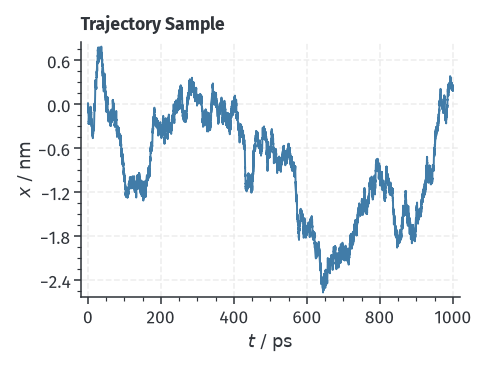

In [3]:
t = np.arange(NSTEPS + 1) * DT
x, _ = mvdlib.diffusion.ld(
    friction=FRICTION,
    nsteps=NSTEPS,
    dt=DT,
    mass=MASS,
    kt=KT,
    x0=0.0,
    rng=np.random.default_rng(42),
)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.plot(t, x, color="C1")
ax.set_xlabel(r"$t\ /\ \mathsf{ps}$")
ax.set_ylabel(r"$x\ /\ \mathsf{nm}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.set_title("Trajectory Sample")
plt.show()

### MSD Analysis

For a free particle, the mean squared displacement approaches $2Dt$ in the long-time limit.

$$
\left<{\left[x(t)-x(0)\right]^2}\right> \to 2Dt
$$


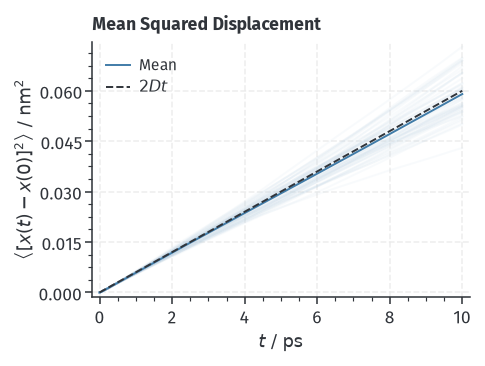

In [4]:
msds = []
rng = np.random.default_rng(42)
for _ in range(NSAMPLES):
    x, _ = mvdlib.diffusion.ld(
        friction=FRICTION,
        nsteps=NSTEPS,
        dt=DT,
        mass=MASS,
        kt=KT,
        x0=0.0,
        rng=rng,
    )
    msds.append(mvdlib.diffusion.msd(x, maxsteps=NSTEPS // 100))

msds = np.transpose(msds)
mean_msd = np.mean(msds, axis=1)
t = np.arange(mean_msd.size) * DT

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.plot(t, msds, color="C4", alpha=0.1)
ax.plot(t, mean_msd, color="C1", label="Mean")
ax.plot(t, 2.0 * DIFF * t, color="C0", ls="--", label="$2Dt$")
ax.legend()
ax.set_xlabel(r"$t\ /\ \mathsf{ps}$")
ax.set_ylabel(r"$\left<{\left[x(t)-x(0)\right]^2}\right>\ /\ \mathsf{nm}^2$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.set_title("Mean Squared Displacement")
plt.show()

## Bounded Particle

Next, we simulate Langevin dynamics in a flat, harmonically bounded potential.


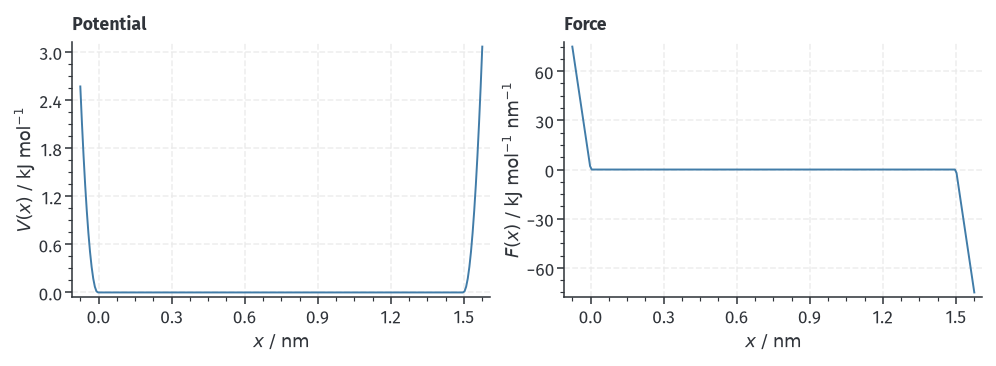

In [5]:
@numba.njit(fastmath=True)
def force_bounded(x, k=FORCE_CONSTANT, w=POTENTIAL_WIDTH):
    if x < 0.0:
        return -k * x
    elif x < w:
        return 0.0
    else:
        return -k * (x - w)


x = np.linspace(-0.05 * POTENTIAL_WIDTH, 1.05 * POTENTIAL_WIDTH, 250)
force = np.array([force_bounded(xi) for xi in x])
potential = -np.cumsum(force) * (x[1] - x[0])
potential -= potential.min()

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE(2), sharex=True)
axes[0].plot(x, potential, color="C1")
axes[1].plot(x, force, color="C1")

for ax in axes:
    ax.set_xlabel(r"$x\ /\ \mathsf{nm}$")
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))

axes[0].set_ylabel(r"$V(x)\ /\ \mathsf{kJ\ mol^{-1}}$")
axes[0].set_title("Potential")
axes[1].set_ylabel(r"$F(x)\ /\ \mathsf{kJ\ mol^{-1}\ nm^{-1}}$")
axes[1].set_title("Force")
plt.show()

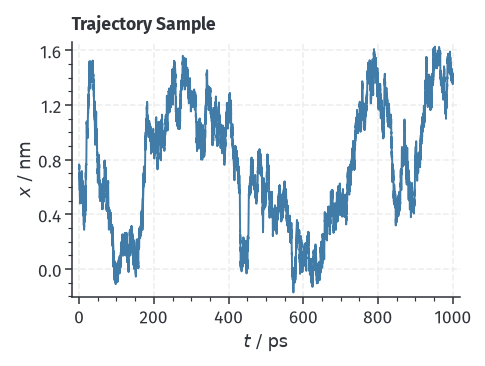

In [6]:
t = np.arange(NSTEPS + 1) * DT
x, _ = mvdlib.diffusion.ld(
    force=force_bounded,
    friction=FRICTION,
    nsteps=NSTEPS,
    dt=DT,
    mass=MASS,
    kt=KT,
    x0=0.5 * POTENTIAL_WIDTH,
    rng=np.random.default_rng(42),
)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.plot(t, x, color="C1")
ax.set_xlabel(r"$t\ /\ \mathsf{ps}$")
ax.set_ylabel(r"$x\ /\ \mathsf{nm}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.set_title("Trajectory Sample")
plt.show()

### MSD Analysis

The mean squared displacement no longer provides a straightforward estimate of the diffusivity.


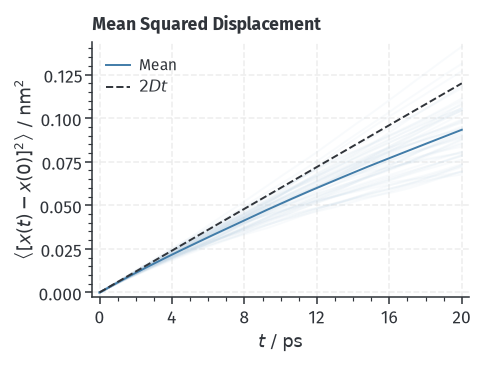

In [7]:
msds = []
rng = np.random.default_rng(42)
for _ in range(NSAMPLES):
    x, _ = mvdlib.diffusion.ld(
        force=force_bounded,
        friction=FRICTION,
        nsteps=NSTEPS,
        dt=DT,
        mass=MASS,
        kt=KT,
        x0=0.5 * POTENTIAL_WIDTH,
        rng=rng,
    )
    msds.append(mvdlib.diffusion.msd(x, maxsteps=NSTEPS // 50))

msds = np.transpose(msds)
mean_msd = np.mean(msds, axis=1)
t = np.arange(mean_msd.size) * DT

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.plot(t, msds, color="C4", alpha=0.1)
ax.plot(t, mean_msd, color="C1", label="Mean")
ax.plot(t, 2.0 * DIFF * t, color="C0", ls="--", label="$2Dt$")
ax.legend()
ax.set_xlabel(r"$t\ /\ \mathsf{ps}$")
ax.set_ylabel(r"$\left<{\left[x(t)-x(0)\right]^2}\right>\ /\ \mathsf{nm}^2$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.set_title("Mean Squared Displacement")
plt.show()

## Inhomogeneous Diffusivity

We continue to study a particle bounded by harmonic walls, but this time, we have a position-dependent diffusivity \(D(x)\). Note that the dynamical bottleneck leads to uneven sampling.


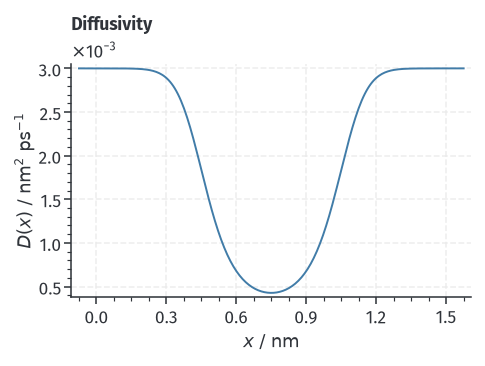

In [8]:
@numba.njit(fastmath=True)
def friction_peak(
        x,
        xc=0.5 * POTENTIAL_WIDTH,
        f0=FRICTION,
        df=FRICTION_SCALE,
        sigma=FRICTION_WIDTH,
):
    return f0 + df * np.exp(-((x - xc) ** 2) / sigma)


x = np.linspace(-0.05 * POTENTIAL_WIDTH, 1.05 * POTENTIAL_WIDTH, 250)
friction = np.array([friction_peak(xi) for xi in x])
diff = KT / friction

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE(), sharex=True)
ax.plot(x, diff, color="C1")
ax.set_xlabel(r"$x\ /\ \mathsf{nm}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.set_ylabel(r"$D(x)\ /\ \mathsf{nm^2\ ps^{-1}}$")
ax.set_title("Diffusivity")
plt.show()

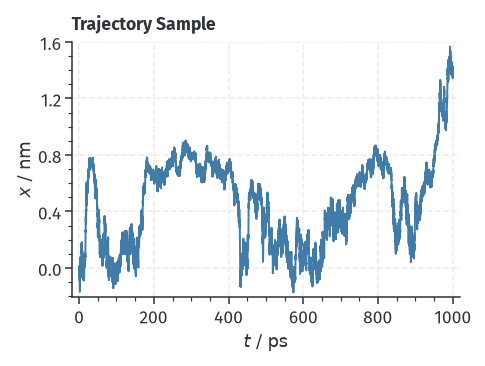

In [9]:
t = np.arange(NSTEPS + 1) * DT
x, _ = mvdlib.diffusion.ld(
    force=force_bounded,
    friction=friction_peak,
    nsteps=NSTEPS,
    dt=DT,
    mass=MASS,
    kt=KT,
    x0=0.0,
    rng=np.random.default_rng(42),
)

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE())
ax.plot(t, x, color="C1")
ax.set_xlabel(r"$t\ /\ \mathsf{ps}$")
ax.set_ylabel(r"$x\ /\ \mathsf{nm}$")
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.set_title("Trajectory Sample")
plt.show()